In [1]:
from google.colab import drive
drive.mount('/content/gdrive')
!ln -s /content/gdrive/My\ Drive/ /mydrive
%cd /mydrive/Pytorch-Models/

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
ln: failed to create symbolic link '/mydrive/My Drive': File exists
/content/gdrive/.shortcut-targets-by-id/1aJsbt04Jz9xcLP_lg7fvP4Bpdce6GQlC/Pytorch-Models


In [ ]:
# STEP 1: Install compatible PyTorch (2.0.1 + CUDA 11.7)
!pip install torch==2.0.1 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu117

# STEP 2: Install OpenMMLab tools
!pip install -U openmim
!mim install "mmengine>=0.7.4"
!mim install "mmcv==2.1.0"

# STEP 3: Clone MMDetection & install
!git clone https://github.com/open-mmlab/mmdetection.git
%cd mmdetection
!pip install -e .

In [2]:
!pip uninstall mmdet -y

Found existing installation: mmdet 3.3.0
Uninstalling mmdet-3.3.0:
  Successfully uninstalled mmdet-3.3.0


In [ ]:
!pip install -U openmim
!mim install "mmdet>=3.0.0rc6, <3.1.0"

In [2]:
!pip uninstall mmcv -y

Found existing installation: mmcv 2.1.0
Uninstalling mmcv-2.1.0:
  Successfully uninstalled mmcv-2.1.0


In [ ]:
!mim install "mmcv>=2.0.0rc4, <2.1.0"

In [2]:
# STEP 4: Final check
!python -c "import torch; import mmcv; import mmdet; print('PyTorch:', torch.__version__); print('MMCV:', mmcv.__version__); print('MMDet:', mmdet.__version__)"

PyTorch: 2.0.1+cu117
MMCV: 2.0.1
MMDet: 3.0.0


In [ ]:
!git clone https://github.com/open-mmlab/mmdeploy.git
%cd mmdeploy
!pip install -e .

In [2]:
!python -c "import mmdeploy; print('MMDeploy:', mmdeploy.__version__)"

MMDeploy: 1.3.1


In [ ]:
!git clone -b 1.x https://github.com/open-mmlab/mmrotate.git
%cd mmrotate
!pip install -e .

In [5]:
# Check MMRotate installation
!python -c "import mmrotate; print('MMRotate:', mmrotate.__version__)"

MMRotate: 1.0.0rc1


In [ ]:
!pip install numpy==1.24.4

In [2]:
!ls mmrotate/configs/rotated_fcos/

metafile.yml
README.md
rotated-fcos-hbox-le90_r50_fpn_1x_dota.py
rotated-fcos-hbox-le90_r50_fpn_csl-gaussian_1x_dota.py
rotated-fcos-le90_r50_fpn_1x_dota.py
rotated-fcos-le90_r50_fpn_kld_1x_dota.py
rotated-fcos-le90_r50_fpn_rr-6x_hrsc.py


In [4]:
from mmdet.apis import init_detector, inference_detector
import mmcv

# Config and checkpoint paths
config_file = 'mmrotate/configs/rotated_fcos/rotated-fcos-le90_r50_fpn_1x_dota.py'
checkpoint_file = 'https://download.openmmlab.com/mmrotate/v0.1.0/rotated_fcos/rotated_fcos_r50_fpn_1x_dota_le90/rotated_fcos_r50_fpn_1x_dota_le90-d87568ed.pth'

# Initialize the model
model = init_detector(config_file, checkpoint_file, device='cuda:0')  # or 'cpu'

# Image path
img = '/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensseg/valid/1B3246F6-8785-4465-AC56-3BE7AA44003D_jpeg.rf.ddd6b9b6921d9589dfae0019661b06a1.jpg'

# Run inference
result = inference_detector(model, img)

# Access the boxes, scores, and labels
print(result.pred_instances.bboxes)
print(result.pred_instances.scores)
print(result.pred_instances.labels)

Loads checkpoint by http backend from path: https://download.openmmlab.com/mmrotate/v0.1.0/rotated_fcos/rotated_fcos_r50_fpn_1x_dota_le90/rotated_fcos_r50_fpn_1x_dota_le90-d87568ed.pth
tensor([[ 1.0563e+03,  1.0534e+03,  5.0055e+01,  1.9989e+02,  3.2936e-01],
        [ 1.0918e+03,  9.5596e+02,  6.9437e+01,  1.8321e+01,  4.8043e-01],
        [ 7.2576e+02,  1.2300e+03,  6.9548e+02,  1.0922e+02, -1.3637e-01],
        [ 1.0992e+03,  8.5853e+02,  1.8103e+01,  5.3879e+01,  4.5540e-01],
        [ 1.0978e+03,  8.6389e+02,  1.8209e+01,  5.2801e+01,  4.7097e-01],
        [ 1.0607e+03,  1.0407e+03,  5.7470e+01,  2.2284e+02,  3.5634e-01],
        [ 7.5201e+02,  1.2122e+03,  5.9723e+02,  1.0393e+02, -1.1469e-01],
        [ 1.1310e+03,  8.7876e+02,  2.0015e+01,  3.7609e+01,  4.3333e-01],
        [ 1.1310e+03,  8.7876e+02,  2.0015e+01,  3.7609e+01,  4.3333e-01],
        [ 7.5201e+02,  1.2122e+03,  5.9723e+02,  1.0393e+02, -1.1469e-01],
        [ 1.0545e+03,  1.0532e+03,  4.9005e+01,  2.0515e+02,  3.4

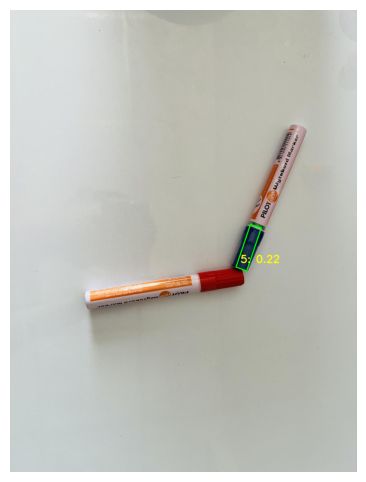

In [5]:
import cv2
import matplotlib.pyplot as plt
import torch
import numpy as np

def draw_rotated_bbox(img, rotated_bbox, label, score, color=(0, 0, 255), thickness=3):
    # rotated_bbox is [x_ctr, y_ctr, w, h, angle]
    x_ctr, y_ctr, w, h, angle = rotated_bbox

    # Calculate the 4 corners of the rotated box
    # angle is in radians in MMRotate 1.x (le90/oc format)
    rect = ((x_ctr, y_ctr), (w, h), np.degrees(angle))
    box = cv2.boxPoints(rect)
    box = np.intp(box)

    # Draw the rotated box
    cv2.drawContours(img, [box], 0, color, thickness)

    # Put label text near the first corner
    cv2.putText(
        img, f"{label}: {score:.2f}", (int(box[0][0]) + 20, int(box[0][1]) - 20),
        cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 255), 3, cv2.LINE_AA
    )

# Access the prediction results
pred_instances = result.pred_instances.cpu()

CONF_THRESHOLD = 0.2

# Load the image pixels (img variable is the path)
img_data = cv2.imread(img)
img_with_results = img_data.copy()

# Draw boxes and labels
for i in range(len(pred_instances.bboxes)):
    score = pred_instances.scores[i].item()
    if score < CONF_THRESHOLD:
        continue

    # Get Class and Color
    label_id = pred_instances.labels[i].item()
    class_name = str(label_id)
    color = (0, 255, 0)

    # Extract rotated bbox [x_ctr, y_ctr, w, h, angle]
    rotated_bbox = pred_instances.bboxes[i].tolist()

    # Draw Rotated Bounding Box
    draw_rotated_bbox(img_with_results, rotated_bbox, class_name, score, color=color)

# Show result
img_rgb = cv2.cvtColor(img_with_results, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 6))
plt.axis('off')
plt.imshow(img_rgb)
plt.show()

In [6]:
import os
import json

def count_images(image_dir, exts={".jpg", ".jpeg", ".png", ".bmp", ".webp"}):
    image_count = 0
    for filename in os.listdir(image_dir):
        if os.path.splitext(filename.lower())[1] in exts:
            image_count += 1
    print(f"Total images: {image_count}")

def count_texts(image_dir, exts={".txt"}):
    text_count = 0
    for filename in os.listdir(image_dir):
        if os.path.splitext(filename.lower())[1] in exts:
            text_count += 1
    print(f"Total texts: {text_count}")

count_images("/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensobb/train/images/")
count_images("/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensobb/valid/images/")
count_texts("/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensobb/train/labels/")
count_texts("/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensobb/valid/labels/")

Total images: 235
Total images: 30
Total texts: 235
Total texts: 30


In [7]:
count_texts("/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensobb/train/labelTxt/")
count_texts("/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensobb/valid/labelTxt/")

Total texts: 235
Total texts: 30


In [ ]:
import os
import cv2

# Settings
# yolo_obb_path = '/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensobb/train/labels/'
# images_path = '/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensobb/train/images/'
# dota_out_path = '/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensobb/train/labelTxt'
yolo_obb_path = '/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensobb/valid/labels/'
images_path = '/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensobb/valid/images/'
dota_out_path = '/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensobb/valid/labelTxt'
os.makedirs(dota_out_path, exist_ok=True)

# class names in order
classes = ["CAP"]

for label_file in os.listdir(yolo_obb_path):
    img_name = label_file.replace('.txt', '.jpg') # or .png
    img = cv2.imread(os.path.join(images_path, img_name))
    h, w, _ = img.shape

    with open(os.path.join(yolo_obb_path, label_file), 'r') as f:
        lines = f.readlines()

    with open(os.path.join(dota_out_path, label_file), 'w') as f_out:
        for line in lines:
            parts = line.split()
            cls_id = int(parts[0])
            coords = [float(x) for x in parts[1:]]

            # 1. Denormalize coordinates (convert 0-1 to actual pixels)
            px_coords = []
            for i in range(0, 8, 2):
                px_coords.append(coords[i] * w)     # x * width
                px_coords.append(coords[i+1] * h)   # y * height

            # 2. Write in DOTA format: x1 y1 x2 y2 x3 y3 x4 y4 class_name 0
            formatted_line = " ".join([f"{c:.2f}" for c in px_coords])
            f_out.write(f"{formatted_line} {classes[cls_id]} 0\n")

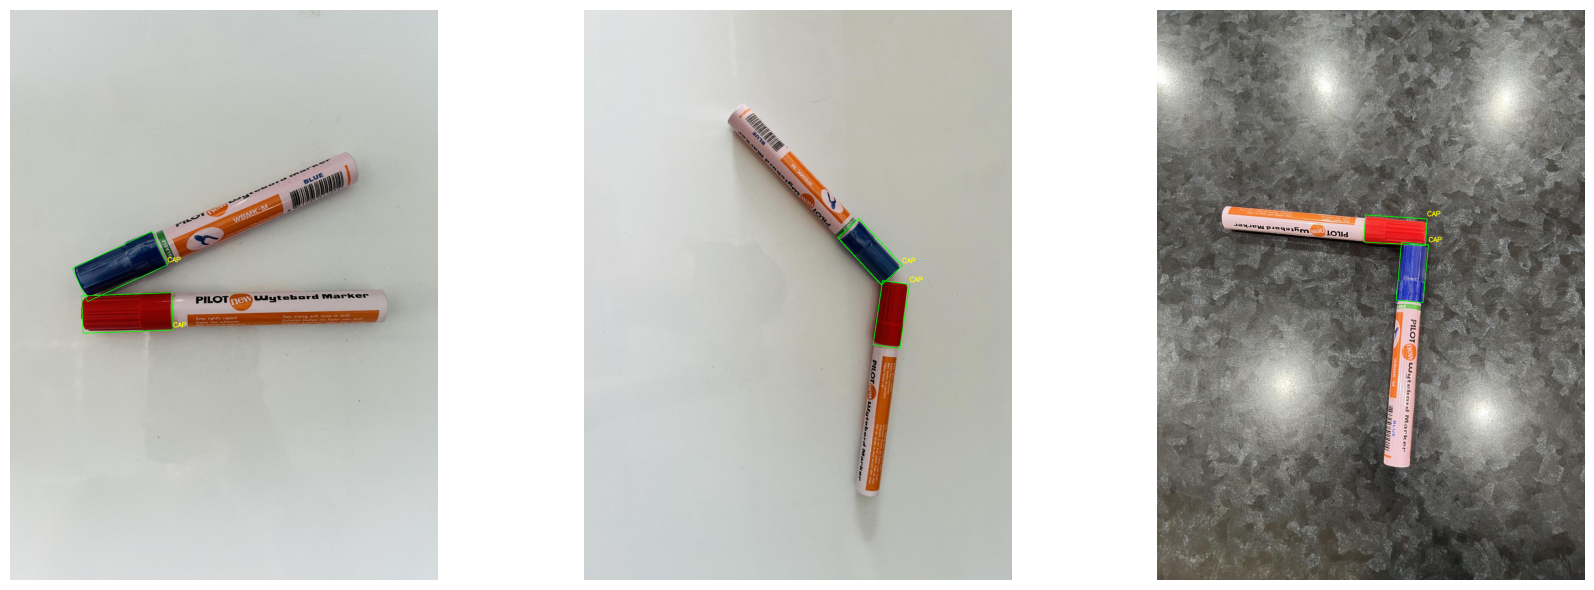

In [8]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np

def debug_dota_visual_grid(img_dir, label_dir, num_samples=3):
    image_files = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
    samples = image_files[:num_samples]

    # Create the grid: 1 row, 3 columns
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for i, img_name in enumerate(samples):
        img_path = os.path.join(img_dir, img_name)
        label_path = os.path.join(label_dir, img_name.rsplit('.', 1)[0] + '.txt')

        img = cv2.imread(img_path)
        if img is None or not os.path.exists(label_path):
            continue

        with open(label_path, 'r') as f:
            for line in f.readlines():
                items = line.strip().split()
                # DOTA: x1 y1 x2 y2 x3 y3 x4 y4 class_name difficulty
                coords = np.array(items[:8], dtype=np.float32).reshape(-1, 2).astype(np.int32)
                class_name = items[8]

                cv2.polylines(img, [coords], isClosed=True, color=(0, 255, 0), thickness=2)
                cv2.putText(img, class_name, (coords[0][0], coords[0][1]-10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 255), 2)

        # Plot in the specific grid column
        ax = axes[i]
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        # ax.set_title(f"Debug: {img_name}", fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Run on valid set
img_folder = "/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensobb/valid/images/"
label_folder = "/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensobb/valid/labelTxt/"
debug_dota_visual_grid(img_folder, label_folder)

In [11]:
custom_cfg = """
_base_ = 'rotated-fcos-le90_r50_fpn_1x_dota.py'

# Custom classes
dataset_type = 'DOTADataset'
metainfo = dict(classes=("CAP",))
num_classes = 1

# Paths
data_root = '/content/gdrive/MyDrive/Pytorch-Models/datasets/'
train_ann = data_root + 'markerpensobb/train/labelTxt/'
val_ann = data_root + 'markerpensobb/valid/labelTxt/'
train_img = data_root + 'markerpensobb/train/images/'
val_img = data_root + 'markerpensobb/valid/images/'

# Pipelines
train_pipeline = [
    dict(type='mmdet.LoadImageFromFile'),
    dict(type='mmdet.LoadAnnotations', with_bbox=True, box_type='qbox'),
    dict(type='ConvertBoxType', box_type_mapping=dict(gt_bboxes='rbox')),
    dict(type='mmdet.Resize', scale=(512, 512), keep_ratio=True),
    dict(
        type='mmdet.RandomFlip',
        prob=0.75,
        direction=['horizontal', 'vertical', 'diagonal']),
    dict(type='mmdet.PackDetInputs')
]
val_pipeline = [
    dict(type='mmdet.LoadImageFromFile'),
    dict(type='mmdet.Resize', scale=(512, 512), keep_ratio=True),
    # avoid bboxes being resized
    dict(type='mmdet.LoadAnnotations', with_bbox=True, box_type='qbox'),
    dict(type='ConvertBoxType', box_type_mapping=dict(gt_bboxes='rbox')),
    dict(
        type='mmdet.PackDetInputs',
        meta_keys=('img_id', 'img_path', 'ori_shape', 'img_shape',
                   'scale_factor'))
]

# Data loader
train_dataloader = dict(
    batch_size=8,
    num_workers=2,
    persistent_workers=True,
    sampler=dict(type='DefaultSampler', shuffle=True),
    batch_sampler=None,
    dataset=dict(
        type=dataset_type,
        data_root=data_root,
        ann_file=train_ann,
        data_prefix=dict(img_path=train_img),
        img_suffix='jpg',
        filter_cfg=dict(filter_empty_gt=True),
        metainfo=metainfo,
        pipeline=train_pipeline))
val_dataloader = dict(
    batch_size=8,
    num_workers=2,
    persistent_workers=True,
    drop_last=False,
    sampler=dict(type='DefaultSampler', shuffle=False),
    dataset=dict(
        type=dataset_type,
        data_root=data_root,
        ann_file=val_ann,
        data_prefix=dict(img_path=val_img),
        img_suffix='jpg',
        test_mode=True,
        metainfo=metainfo,
        pipeline=val_pipeline))

test_dataloader = val_dataloader

# Evaluator
val_evaluator = dict(type='DOTAMetric', metric='mAP')
test_evaluator = val_evaluator

# Model
angle_version = 'le90'
model = dict(
    type='mmdet.FCOS',
    data_preprocessor=dict(
        type='mmdet.DetDataPreprocessor',
        mean=[123.675, 116.28, 103.53],
        std=[58.395, 57.12, 57.375],
        bgr_to_rgb=True,
        pad_size_divisor=32,
        boxtype2tensor=False),
    backbone=dict(
        type='mmdet.ResNet',
        depth=50,
        num_stages=4,
        out_indices=(0, 1, 2, 3),
        frozen_stages=1,
        norm_cfg=dict(type='BN', requires_grad=True),
        norm_eval=True,
        style='pytorch',
        init_cfg=dict(type='Pretrained', checkpoint='torchvision://resnet50')),
    neck=dict(
        type='mmdet.FPN',
        in_channels=[256, 512, 1024, 2048],
        out_channels=256,
        start_level=1,
        add_extra_convs='on_output',
        num_outs=5,
        relu_before_extra_convs=True),
    bbox_head=dict(
        type='RotatedFCOSHead',
        num_classes=num_classes,
        in_channels=256,
        stacked_convs=4,
        feat_channels=256,
        strides=[8, 16, 32, 64, 128],
        center_sampling=True,
        center_sample_radius=1.5,
        norm_on_bbox=True,
        centerness_on_reg=True,
        use_hbbox_loss=False,
        scale_angle=True,
        bbox_coder=dict(
            type='DistanceAnglePointCoder', angle_version=angle_version),
        loss_cls=dict(
            type='mmdet.FocalLoss',
            use_sigmoid=True,
            gamma=2.0,
            alpha=0.25,
            loss_weight=1.0),
        loss_bbox=dict(type='RotatedIoULoss', loss_weight=1.0),
        loss_angle=None,
        loss_centerness=dict(
            type='mmdet.CrossEntropyLoss', use_sigmoid=True, loss_weight=1.0)),
    # training and testing settings
    train_cfg=None,
    test_cfg=dict(
        nms_pre=2000,
        min_bbox_size=0,
        score_thr=0.05,
        nms=dict(type='nms_rotated', iou_threshold=0.1),
        max_per_img=2000))

# Schedule
train_cfg = dict(type='EpochBasedTrainLoop', max_epochs=10, val_interval=1)
val_cfg = dict(type='ValLoop')
test_cfg = dict(type='TestLoop')

# Optimizer
optim_wrapper = dict(
    optimizer=dict(type='SGD', lr=0.005, momentum=0.9, weight_decay=0.0001),
    clip_grad=None
)

# Learning policy
param_scheduler = [
    dict(type='LinearLR', start_factor=0.01, by_epoch=False, begin=0, end=30),
    dict(
        type='MultiStepLR',
        begin=0,
        end=10,
        by_epoch=True,
        milestones=[7, 9],
        gamma=0.1
    )
]

# Logging and checkpointing
default_hooks = dict(
    logger=dict(type='LoggerHook', interval=2),
    checkpoint=dict(
        type='CheckpointHook',
        interval=2,
        save_best='dota/mAP',
        rule='greater'
    ),
)

# Output path
work_dir = '/content/gdrive/MyDrive/Pytorch-Models/mmrotate/mmrotate_outputs/rotated-fcos-markers'

# Load pretrained COCO model
load_from = 'https://download.openmmlab.com/mmrotate/v0.1.0/rotated_fcos/rotated_fcos_r50_fpn_1x_dota_le90/rotated_fcos_r50_fpn_1x_dota_le90-d87568ed.pth'
"""

with open('mmrotate/configs/rotated_fcos/rotated-fcos-markers.py', 'w') as f:
    f.write(custom_cfg)

In [12]:
!python mmrotate/tools/train.py mmrotate/configs/rotated_fcos/rotated-fcos-markers.py --amp

Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1+cu117
03/04 06:31:00 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 1334092457
    GPU 0: Tesla T4
    CUDA_HOME: /usr/local/cuda
    NVCC: Cuda compilation tools, release 12.5, V12.5.82
    GCC: x86_64-linux-gnu-gcc (Ubuntu 11.4.0-1ubuntu1~22.04) 11.4.0
    PyTorch: 2.0.1+cu117
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.7.3 (Git Hash 6dbeffbae1f23cbbeae17adb7b5b13f1f37c080e)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX2
  - CUDA 

In [13]:
!python mmrotate/tools/test.py mmrotate/configs/rotated_fcos/rotated-fcos-markers.py mmrotate/mmrotate_outputs/rotated-fcos-markers/epoch_10.pth

Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1+cu117
03/04 06:38:23 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 869746873
    GPU 0: Tesla T4
    CUDA_HOME: /usr/local/cuda
    NVCC: Cuda compilation tools, release 12.5, V12.5.82
    GCC: x86_64-linux-gnu-gcc (Ubuntu 11.4.0-1ubuntu1~22.04) 11.4.0
    PyTorch: 2.0.1+cu117
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.7.3 (Git Hash 6dbeffbae1f23cbbeae17adb7b5b13f1f37c080e)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX2
  - CUDA R

In [14]:
from mmdet.apis import init_detector, inference_detector
import mmcv

# Config and checkpoint paths
config_file = 'mmrotate/configs/rotated_fcos/rotated-fcos-markers.py'
checkpoint_file = 'mmrotate/mmrotate_outputs/rotated-fcos-markers/epoch_10.pth'

# Initialize the model
model = init_detector(config_file, checkpoint_file, device='cuda:0')  # or 'cpu'

# Image path
img = '/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensobb/valid/images/6A1EFB9C-7F57-432F-8217-DE794D112A47_jpeg.rf.c70569edcee92d13ec59d613a6663bed.jpg'

# Run inference
result = inference_detector(model, img)

# Access the boxes, scores, and labels
print(result.pred_instances.bboxes)
print(result.pred_instances.scores)
print(result.pred_instances.labels)

Loads checkpoint by local backend from path: mmrotate/mmrotate_outputs/rotated-fcos-markers/epoch_10.pth
tensor([[8.1323e+02, 7.2019e+02, 9.3823e+01, 2.1279e+02, 8.6595e-01],
        [8.8572e+02, 8.3237e+02, 9.0271e+01, 2.0978e+02, 9.5626e-02]],
       device='cuda:0')
tensor([0.7834, 0.6751], device='cuda:0')
tensor([0, 0], device='cuda:0')


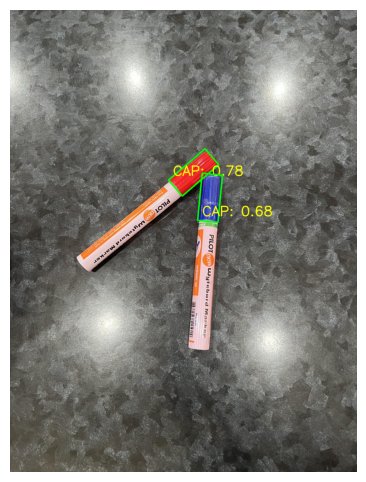

In [15]:
import cv2
import matplotlib.pyplot as plt
import torch
import numpy as np
import os
import random

# Class labels
CLASS_LABELS = ["CAP"]

PRED_COLORS = {0: (0, 255, 0)}

def draw_rotated_bbox(img, rotated_bbox, label, score, color=(0, 0, 255), thickness=5):
    # rotated_bbox is [x_ctr, y_ctr, w, h, angle]
    x_ctr, y_ctr, w, h, angle = rotated_bbox

    # Calculate the 4 corners of the rotated box
    # angle is in radians in MMRotate 1.x (le90/oc format)
    rect = ((x_ctr, y_ctr), (w, h), np.degrees(angle))
    box = cv2.boxPoints(rect)
    box = np.intp(box)

    # Draw the rotated box
    cv2.drawContours(img, [box], 0, color, thickness)

    # Put label text near the first corner
    cv2.putText(
        img, f"{label}: {score:.2f}", (int(box[0][0]) + 20, int(box[0][1]) - 20),
        cv2.FONT_HERSHEY_SIMPLEX, 2.0, (0, 255, 255), 4, cv2.LINE_AA
    )

# Access the prediction results
pred_instances = result.pred_instances.cpu()

CONF_THRESHOLD = 0.5

# Load the image pixels (img variable is the path)
img_data = cv2.imread(img)
img_with_results = img_data.copy()

# Draw boxes and labels
for i in range(len(pred_instances.bboxes)):
    score = pred_instances.scores[i].item()
    if score < CONF_THRESHOLD:
        continue

    # Get Class and Color
    label_id = pred_instances.labels[i].item()

    class_name = CLASS_LABELS[label_id]
    color = PRED_COLORS[label_id]

    # Extract rotated bbox [x_ctr, y_ctr, w, h, angle]
    rotated_bbox = pred_instances.bboxes[i].tolist()

    # Draw Rotated Bounding Box
    draw_rotated_bbox(img_with_results, rotated_bbox, class_name, score, color=color)

# Show result
img_rgb = cv2.cvtColor(img_with_results, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 6))
plt.axis('off')
plt.imshow(img_rgb)
plt.show()

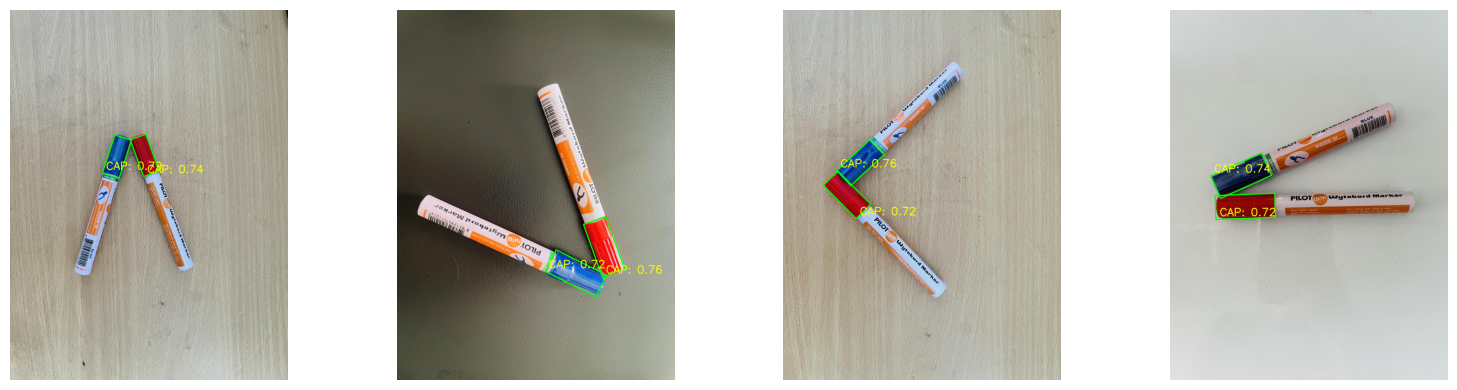

In [20]:
# ---------------- CONFIG ----------------
val_dir = "/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensobb/valid/images/"

# visualization layout
N = 4
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 4 * rows))

for ii, image in enumerate(sample_imgs):
    plt.subplot(1, 4, ii+1)

    img = cv2.imread(image)

    results = inference_detector(model, image)

    pred_instances = results.pred_instances.cpu()

    CONF_THRESHOLD = 0.5
    img_with_results = img.copy()

    # Draw boxes and labels
    for i in range(len(pred_instances.bboxes)):
        score = pred_instances.scores[i].item()
        if score < CONF_THRESHOLD:
            continue

        # Get Class and Color
        label_id = pred_instances.labels[i].item()

        class_name = CLASS_LABELS[label_id]
        color = PRED_COLORS[label_id]

        # Extract rotated bbox [x_ctr, y_ctr, w, h, angle]
        rotated_bbox = pred_instances.bboxes[i].tolist()

        # Draw Rotated Bounding Box
        draw_rotated_bbox(img_with_results, rotated_bbox, class_name, score, color=color)

    plt.subplot(rows, cols, ii + 1)
    plt.imshow(cv2.cvtColor(img_with_results, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:
!pip install onnx onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 110.4 MB/s eta 0:00:00
  Attempting uninstall: ml_dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.5.2 requires numpy>=1.25, but you have numpy 1.24.4 which is incompatible.
jaxlib 0.5.1 requires numpy>=1.25, but you have numpy 1.24.4 which is incompatible.
tensorflow 2.18.0 requires ml-dtypes<0.5.0,>=0.4.0, but you have ml-dtypes 0.5.4 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 1.24.4 which is incompatible.
tensorflow 2.18.0 requires protobuf!=4.21.0,!=4.21.1,!

In [22]:
!pip install onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 100.9 MB/s eta 0:00:00


In [25]:
import torch
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)

cuda


In [26]:
dummy_input = torch.randn(1, 3, 512, 512).to(device)
onnx_model_path = "mmrotate/mmrotate_outputs/rotated-fcos-markers/epoch_10.onnx"
torch.onnx.export(
    model,
    dummy_input,
    onnx_model_path,
    opset_version=13,
    input_names=["input"],
    output_names=["boxes", "labels", "scores"],
    do_constant_folding=True,
)
print(f"ONNX export {onnx_model_path} completed successfully!")

============= Diagnostic Run torch.onnx.export version 2.0.1+cu117 =============
verbose: False, log level: Level.ERROR
======================= 0 NONE 0 NOTE 0 WARNING 0 ERROR ========================

ONNX export mmrotate/mmrotate_outputs/rotated-fcos-markers/epoch_10.onnx completed successfully!


In [101]:
import onnxruntime
import numpy as np
import cv2
import torch

# Load image and preprocess
img_path = "/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensobb/valid/images/6A1EFB9C-7F57-432F-8217-DE794D112A47_jpeg.rf.c70569edcee92d13ec59d613a6663bed.jpg"

mean = np.array([123.675, 116.28, 103.53], dtype=np.float32)
std = np.array([58.395, 57.12, 57.375], dtype=np.float32)

img = cv2.imread(img_path)
img_resized = cv2.resize(img, (512, 512))
img_input = (img_resized[:, :, ::-1].astype(np.float32) - mean) / std
img_input = img_input.transpose(2, 0, 1)[np.newaxis, :]  # (1, 3, H, W)

# Run inference
session = onnxruntime.InferenceSession("mmrotate/mmrotate_outputs/rotated-fcos-markers/epoch_10.onnx", providers=["CPUExecutionProvider"])
input_name = session.get_inputs()[0].name
outputs = session.run(None, {input_name: img_input})

# outputs is a list, often like [boxes, scores, keypoints]
print("Output:", [o.shape for o in outputs])

Output: [(1, 1, 64, 64), (1, 1, 32, 32), (1, 1, 16, 16), (1, 1, 8, 8), (1, 1, 4, 4), (1, 4, 64, 64), (1, 4, 32, 32), (1, 4, 16, 16), (1, 4, 8, 8), (1, 4, 4, 4), (1, 1, 64, 64), (1, 1, 32, 32), (1, 1, 16, 16), (1, 1, 8, 8), (1, 1, 4, 4), (1, 1, 64, 64), (1, 1, 32, 32), (1, 1, 16, 16), (1, 1, 8, 8), (1, 1, 4, 4)]


Drawing 2 boxes after NMS. Max Score: 0.8527


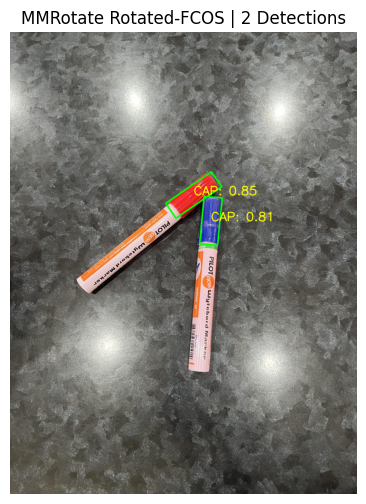

In [102]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# --- 1. Image & Scaling Setup ---
orig_h, orig_w = img.shape[:2]
# Model input was 512x512
scale_w, scale_h = orig_w / 512.0, orig_h / 512.0

def get_points(h, w, stride):
    """Generate anchor points for FCOS."""
    x_range = (np.arange(w) + 0.5) * stride
    y_range = (np.arange(h) + 0.5) * stride
    x, y = np.meshgrid(x_range, y_range)
    return np.stack((x.flatten(), y.flatten()), axis=-1)

def decode_rotated_boxes(points, bbox_pred, angle_pred, scale_w, scale_h):
    l, t, r, b = [bbox_pred[:, i] for i in range(4)]
    theta = angle_pred.flatten()

    # 1. Projected Center in 512 space
    cos_t, sin_t = np.cos(theta), np.sin(theta)

    # Sub-pixel correction: ensure offsets are handled in 512 float space
    offset_x = (r - l) / 2.0
    offset_y = (b - t) / 2.0

    x_512 = points[:, 0] + offset_x * cos_t - offset_y * sin_t
    y_512 = points[:, 1] + offset_x * sin_t + offset_y * cos_t

    # 2. Scale back to original image
    # Note: We do NOT recalculate theta with arctan2 here (as it made it worse)
    return np.stack((x_512 * scale_w, y_512 * scale_h, (l+r) * scale_w, (t+b) * scale_h, theta), axis=-1)

# --- 2. Organize Outputs ---
# MMRotate Typical Order: 0-4: Cls, 5-9: Reg, 10-14: Angle, 15-19: Centerness
strides = [8, 16, 32, 64, 128]
all_boxes, all_scores = [], []

for i in range(5):
    stride = strides[i]

    # 1. Classification (Try indices 0-4)
    cls_logits = outputs[i][0, 0]
    cls_score = 1 / (1 + np.exp(-cls_logits))

    # 2. Centerness (Try indices 15-19)
    cnt_logits = outputs[i+15][0, 0]
    cnt_score = 1 / (1 + np.exp(-cnt_logits))

    # 3. Regression (5-9) - Scale by stride ONLY if values are small (< 10)
    # If raw values are large (e.g. 50), the stride is already applied in ONNX
    reg_map = outputs[i+5][0]
    if np.mean(reg_map) < 10:
        reg_map = reg_map * stride

    # 4. Angle (10-14)
    ang_map = outputs[i+10][0, 0]

    h, w = cls_score.shape
    points = get_points(h, w, stride)

    # Score = sqrt(Cls * Centerness)
    # If score is still 0.06, swap cls_logits with cnt_logits
    level_scores = np.sqrt(cls_score.flatten() * cnt_score.flatten())
    level_bboxes = reg_map.reshape(4, -1).T
    level_angles = ang_map.flatten()

    level_decoded = decode_rotated_boxes(points, level_bboxes, level_angles, scale_w, scale_h)

    all_boxes.append(level_decoded)
    all_scores.append(level_scores)

final_boxes = np.vstack(all_boxes)
final_scores = np.concatenate(all_scores)

# --- 3. NMS and Visualization ---
CONF_THRESHOLD = 0.5
NMS_THRESHOLD = 0.3
CLASS_LABELS = ["CAP"]

# Prepare data for cv2.dnn.NMSBoxesRotated
# Format: List of ((x, y), (w, h), angle_degrees)
# --- Updated NMS with le90 Normalization ---
nms_boxes, nms_scores = [], []
for i in range(len(final_boxes)):
    if final_scores[i] > CONF_THRESHOLD:
        x, y, w, h, a = final_boxes[i]

        angle_deg = np.degrees(a)

        # Step 1: Wrap to [-180, 180)
        angle_deg = (angle_deg + 180) % 360 - 180

        # Step 2: Convert to le90 [-90, 90)
        if angle_deg < -90:
            angle_deg += 180
        elif angle_deg >= 90:
            angle_deg -= 180

        # Step 3: Convert to OpenCV format [-90, 0)
        if angle_deg >= 0:
            angle_deg -= 90
            w, h = h, w

        nms_boxes.append(((float(x), float(y)), (float(w), float(h)), angle_deg))
        nms_scores.append(float(final_scores[i]))

indices = cv2.dnn.NMSBoxesRotated(nms_boxes, nms_scores, CONF_THRESHOLD, NMS_THRESHOLD)

visual_img = img.copy()
count = 0

if len(indices) > 0:
    for i in indices.flatten():
        box_data = nms_boxes[i]
        score = nms_scores[i]

        # Get corner points for drawing
        poly = cv2.boxPoints(box_data).astype(np.int32)

        # Draw Polygon
        cv2.polylines(visual_img, [poly], True, (0, 255, 0), 5)

        # Draw Label and Score
        label_text = f"{CLASS_LABELS[0]}: {score:.2f}"
        x_text, y_text = int(box_data[0][0]), int(box_data[0][1])
        cv2.putText(visual_img, label_text, (x_text, y_text),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.8, (0, 255, 255), 4)
        count += 1

print(f"Drawing {count} boxes after NMS. Max Score: {np.max(final_scores):.4f}")

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(visual_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f"MMRotate Rotated-FCOS | {count} Detections")
plt.show()

In [111]:
print(np.min(final_boxes[:,4]), np.max(final_boxes[:,4]))

-7.228869438171387 -5.889389991760254


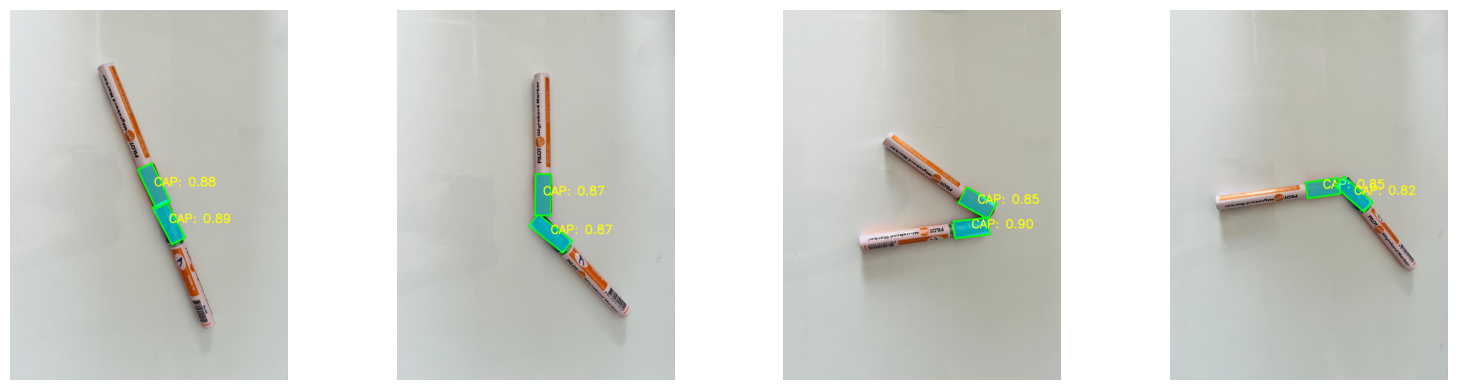

In [109]:
import numpy as np
import os
import random
# ---------------- CONFIG ----------------
val_dir = "/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensseg/valid/"

# visualization layout
N = 4
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 4 * rows))

for ii, image in enumerate(sample_imgs):
    plt.subplot(1, 4, ii+1)

    img = cv2.imread(image)
    img_resized = cv2.resize(img, (512, 512))
    img_input = (img_resized[:, :, ::-1].astype(np.float32) - mean) / std
    img_input = img_input.transpose(2, 0, 1)[np.newaxis, :]  # (1, 3, H, W)

    outputs = session.run(None, {input_name: img_input})

    orig_h, orig_w = img.shape[:2]
    scale_w, scale_h = orig_w / 512.0, orig_h / 512.0

    strides = [8, 16, 32, 64, 128]
    all_boxes, all_scores = [], []

    for i in range(5):
        stride = strides[i]

        # 1. Classification (Try indices 0-4)
        cls_logits = outputs[i][0, 0]
        cls_score = 1 / (1 + np.exp(-cls_logits))

        # 2. Centerness (Try indices 15-19)
        cnt_logits = outputs[i+15][0, 0]
        cnt_score = 1 / (1 + np.exp(-cnt_logits))

        # 3. Regression (5-9) - Scale by stride ONLY if values are small (< 10)
        # If raw values are large (e.g. 50), the stride is already applied in ONNX
        reg_map = outputs[i+5][0]
        if np.mean(reg_map) < 10:
            reg_map = reg_map * stride

        # 4. Angle (10-14)
        ang_map = outputs[i+10][0, 0]

        h, w = cls_score.shape
        points = get_points(h, w, stride)

        # Score = sqrt(Cls * Centerness)
        # If score is still 0.06, swap cls_logits with cnt_logits
        level_scores = np.sqrt(cls_score.flatten() * cnt_score.flatten())
        level_bboxes = reg_map.reshape(4, -1).T
        level_angles = ang_map.flatten()

        level_decoded = decode_rotated_boxes(points, level_bboxes, level_angles, scale_w, scale_h)

        all_boxes.append(level_decoded)
        all_scores.append(level_scores)

    final_boxes = np.vstack(all_boxes)
    final_scores = np.concatenate(all_scores)

    # --- 3. NMS and Visualization ---
    CONF_THRESHOLD = 0.5
    NMS_THRESHOLD = 0.3
    CLASS_LABELS = ["CAP"]

    nms_boxes, nms_scores = [], []
    for i in range(len(final_boxes)):
        if final_scores[i] > CONF_THRESHOLD:
            x, y, w, h, a = final_boxes[i]

            angle_deg = np.degrees(a)

            # Step 1: Wrap to [-180, 180)
            angle_deg = (angle_deg + 180) % 360 - 180

            # Step 2: Convert to le90 [-90, 90)
            if angle_deg < -90:
                angle_deg += 180
            elif angle_deg >= 90:
                angle_deg -= 180

            # Step 3: Convert to OpenCV format [-90, 0)
            if angle_deg >= 0:
                angle_deg -= 90
                w, h = h, w

            nms_boxes.append(((float(x), float(y)), (float(w), float(h)), angle_deg))
            nms_scores.append(float(final_scores[i]))

    indices = cv2.dnn.NMSBoxesRotated(nms_boxes, nms_scores, CONF_THRESHOLD, NMS_THRESHOLD)
    visual_img = img.copy()

    if len(indices) > 0:
        for i in indices.flatten():
            box_data = nms_boxes[i]
            score = nms_scores[i]

            # Get corner points for drawing
            poly = cv2.boxPoints(box_data).astype(np.int32)
            roi = visual_img.copy()
            cv2.fillPoly(roi, [poly], (255, 255, 0)) # Cyan
            cv2.addWeighted(roi, 0.6, visual_img, 0.4, 0, visual_img)

            # Draw Polygon
            cv2.polylines(visual_img, [poly], True, (0, 255, 0), 8)

            # Draw Label and Score
            label_text = f"{CLASS_LABELS[0]}: {score:.2f}"
            x_text, y_text = int(box_data[0][0]), int(box_data[0][1])
            cv2.putText(visual_img, label_text, (x_text, y_text),
                        cv2.FONT_HERSHEY_SIMPLEX, 2.2, (0, 255, 255), 5)

    plt.subplot(rows, cols, ii + 1)
    plt.imshow(cv2.cvtColor(visual_img, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.tight_layout()
plt.show()